In [1]:
from geod67lib import fd

import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt

2026-06-22 11:32:48.215043: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
coeffs = fd.taylor_coeffs(2)[1]
coeffs = np.flip(coeffs)
coeffs

array([ 0.08333334, -0.6666667 , -0.        ,  0.6666667 , -0.08333334],
      dtype=float32)

In [4]:
fd.taylor_coeffs(2).shape

(5, 5)

In [4]:
x = tf.zeros((5,5))
x

<tf.Tensor: shape=(5, 5), dtype=float32, numpy=
array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)>

In [14]:
tf.sparse.add(x, tf.SparseTensor([(2,2)], values=[1.1], dense_shape=x.shape))

<tf.Tensor: shape=(5, 5), dtype=float32, numpy=
array([[0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1.1, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. ]], dtype=float32)>

In [8]:
n = coeffs.shape[0]
kernel = np.zeros((n,n,1,1))

In [15]:
f = tf.constant(np.random.random((1, 4*n, 4*n, 1)))
f

<tf.Tensor: shape=(1, 20, 20, 1), dtype=float64, numpy=
array([[[[0.20755101],
         [0.2238132 ],
         [0.16246179],
         [0.87929017],
         [0.11905068],
         [0.86896926],
         [0.06114023],
         [0.51683934],
         [0.36201416],
         [0.07389634],
         [0.54139056],
         [0.98479319],
         [0.47275947],
         [0.34816623],
         [0.92765727],
         [0.32795098],
         [0.80777079],
         [0.70681281],
         [0.32717612],
         [0.19615101]],

        [[0.59431749],
         [0.36341546],
         [0.33039228],
         [0.27008207],
         [0.68239833],
         [0.18523713],
         [0.33813472],
         [0.91629912],
         [0.38812117],
         [0.32335951],
         [0.10928756],
         [0.11356304],
         [0.41683107],
         [0.91789241],
         [0.07184785],
         [0.17115841],
         [0.61665452],
         [0.19903668],
         [0.01248375],
         [0.11949854]],

        [[0.03105268

In [16]:
kernel[:, n//2, 0, 0] = coeffs
kernel = tf.constant(kernel)
kernel

<tf.Tensor: shape=(5, 5, 1, 1), dtype=float64, numpy=
array([[[[ 0.        ]],

        [[ 0.        ]],

        [[ 0.08333334]],

        [[ 0.        ]],

        [[ 0.        ]]],


       [[[ 0.        ]],

        [[ 0.        ]],

        [[-0.66666669]],

        [[ 0.        ]],

        [[ 0.        ]]],


       [[[ 0.        ]],

        [[ 0.        ]],

        [[-0.        ]],

        [[ 0.        ]],

        [[ 0.        ]]],


       [[[ 0.        ]],

        [[ 0.        ]],

        [[ 0.66666669]],

        [[ 0.        ]],

        [[ 0.        ]]],


       [[[ 0.        ]],

        [[ 0.        ]],

        [[-0.08333334]],

        [[ 0.        ]],

        [[ 0.        ]]]])>

In [18]:
tf.nn.conv2d(f, kernel, 1, padding='SAME')

<tf.Tensor: shape=(1, 20, 20, 1), dtype=float64, numpy=
array([[[[ 0.39362395],
         [ 0.18886108],
         [ 0.16581496],
         [ 0.11418846],
         [ 0.42012378],
         [ 0.04963602],
         [ 0.15713332],
         [ 0.53553792],
         [ 0.21931014],
         [ 0.16892669],
         [ 0.02033624],
         [-0.00155729],
         [ 0.24270391],
         [ 0.55663925],
         [-0.03114572],
         [ 0.09727275],
         [ 0.3997194 ],
         [ 0.11695066],
         [ 0.00340265],
         [ 0.06941944]],

        [[-0.14683259],
         [ 0.27727819],
         [ 0.26691303],
         [-0.09505338],
         [ 0.18295884],
         [-0.0170031 ],
         [ 0.46369631],
         [ 0.22271286],
         [ 0.0489581 ],
         [ 0.29872062],
         [ 0.02207496],
         [-0.08849256],
         [-0.04392343],
         [ 0.12996068],
         [-0.02580891],
         [-0.13916733],
         [-0.48287431],
         [-0.36737812],
         [-0.26031243],
      

In [13]:
for i in range(coeffs.shape[0]):
    print(i - 4)

-4
-3
-2
-1
0
1
2
3
4


array([[ 1,  2,  3,  4,  5],
       [ 2,  4,  6,  8, 10],
       [ 3,  6,  9, 12, 15],
       [ 4,  8, 12, 16, 20],
       [ 5, 10, 15, 20, 25]])

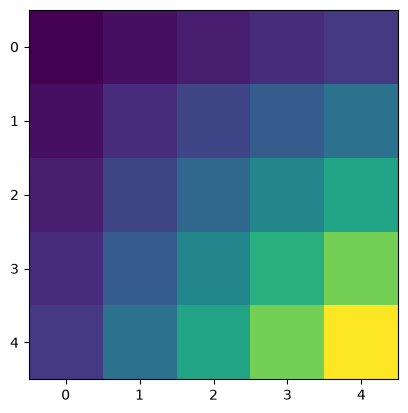

In [3]:
A = np.array([ (np.arange(5) + 1) * (i + 1) for i in range(5) ])
plt.imshow(A)
A

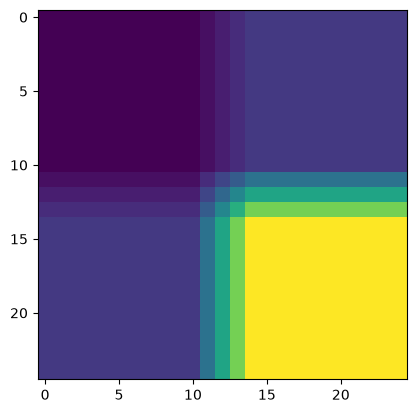

In [4]:
plt.imshow(np.pad(A, 10, mode='edge'))

array([[ 1,  1,  1,  1,  2],
       [ 2,  2,  2,  2,  4],
       [ 3,  3,  3,  3,  6],
       [ 4,  4,  4,  4,  8],
       [ 5,  5,  5,  5, 10]])

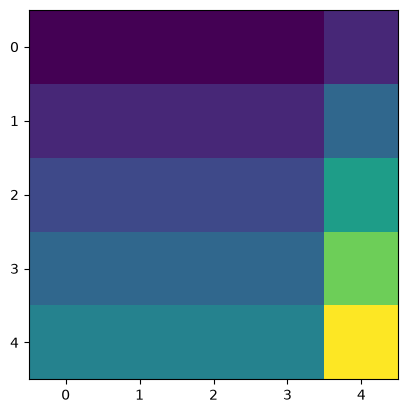

In [5]:
B = fd.shift2d(A, -3, 1)
plt.imshow(B)
B

(<matplotlib.image.AxesImage at 0x7f2bb0334610>,
 array([[ 1,  1,  2,  3,  4],
        [ 2,  2,  4,  6,  8],
        [ 3,  3,  6,  9, 12],
        [ 4,  4,  8, 12, 16],
        [ 5,  5, 10, 15, 20]]))

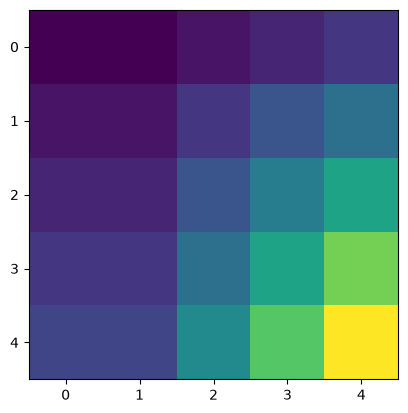

In [6]:
B = fd.shift(A, -1, 1, mode='edge')
plt.imshow(B), B